In [14]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from PIL import Image
import requests
from io import BytesIO

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


In [38]:
BREED_A_ID = 0
BREED_B_ID = 8

dataset, info = tfds.load('oxford_iiit_pet', with_info=True, as_supervised=True)

def filter_breeds(image, label):
    return tf.equal(label, BREED_A_ID) or tf.equal(label, BREED_B_ID)

def map_to_binary(image, label):
    binary_label = tf.where(tf.equal(label, BREED_B_ID), 1, 0)
    return image, binary_label

train_ds_raw = dataset['train'].filter(filter_breeds).map(map_to_binary)
test_ds_raw = dataset['test'].filter(filter_breeds).map(map_to_binary)

binary_class_names = ['Abyssinian', 'Ragdoll']
print(f"Датасет відфільтровано. Класи: {binary_class_names}")

Датасет відфільтровано. Класи: ['Abyssinian', 'Ragdoll']


In [39]:
IMG_SIZE = 299
BATCH_SIZE = 16

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

def preprocess_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = (image / 127.5) - 1.0 
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.map(preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(2000).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds_raw.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

In [40]:
def inception_block(x, filters):
    branch1 = layers.Conv2D(filters, 1, activation='relu', padding='same')(x)
    
    branch2 = layers.Conv2D(filters, 1, activation='relu', padding='same')(x)
    branch2 = layers.Conv2D(filters, 3, activation='relu', padding='same')(branch2)
    
    branch3 = layers.Conv2D(filters, 1, activation='relu', padding='same')(x)
    branch3 = layers.Conv2D(filters, 5, activation='relu', padding='same')(branch3)
    
    branch4 = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    branch4 = layers.Conv2D(filters, 1, activation='relu', padding='same')(branch4)
    
    return layers.Concatenate(axis=-1)([branch1, branch2, branch3, branch4])

def create_binary_inception(input_shape=(299, 299, 3)):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
    x = inception_block(x, 64)
    x = inception_block(x, 128)
    
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Binary_Inception_Pet")

model = create_binary_inception()

In [41]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])
EPOCHS = 30
history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/30
     13/Unknown 10s 123ms/step - accuracy: 0.4611 - loss: 0.7319

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 491ms/step - accuracy: 0.4628 - loss: 0.7303 - val_accuracy: 0.5178 - val_loss: 0.6876
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.5311 - loss: 0.6834 - val_accuracy: 0.5685 - val_loss: 0.6814
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.6441 - loss: 0.6685 - val_accuracy: 0.6396 - val_loss: 0.6599
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.6714 - loss: 0.6515 - val_accuracy: 0.6345 - val_loss: 0.6460
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.5919 - loss: 0.6441 - val_accuracy: 0.6701 - val_loss: 0.6282
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.7572 - loss: 0.6015 - val_accuracy: 0.6497 - val_loss: 0.6381
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.7018 - loss: 0.6085 - val_accuracy: 0.6447 - val_loss: 0.6490
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.7189 - loss: 0.5921 - val_accuracy: 0.5482 - val


--- Оцінка моделі (Бінарна) ---
Accuracy:  0.7259
Precision: 0.7064
Recall:    0.7778
F1-Score:  0.7404


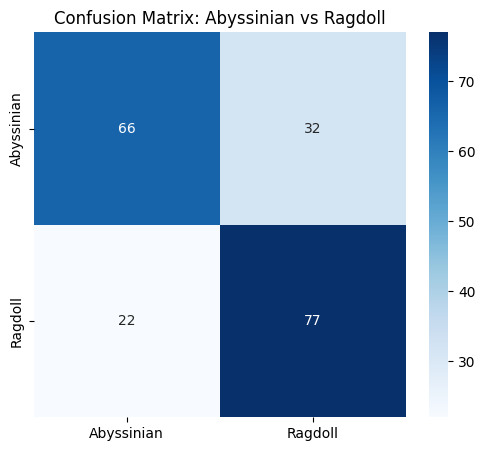

In [42]:
print("\n--- Оцінка моделі (Бінарна) ---")
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int).flatten()

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title('Confusion Matrix: Abyssinian vs Ragdoll')
plt.show()

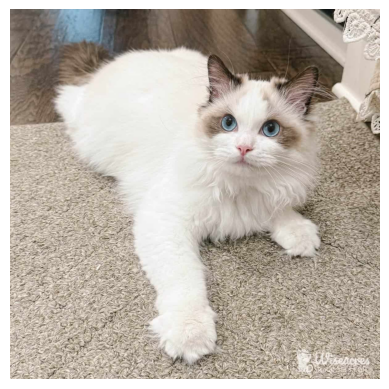

Результат розпізнавання: Ragdoll
Впевненість моделі: 78.90%


In [45]:
def predict_pet(model, url):
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
        
        resp = requests.get(url, headers=headers, timeout=10)
        resp.raise_for_status() # Перевірка, чи запит успішний
        
        img = Image.open(BytesIO(resp.content)).convert('RGB')
        img_resized = img.resize((299, 299))
        
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
        img_arr = (np.array(img_resized) / 127.5) - 1.0
        img_tensor = np.expand_dims(img_arr, 0)
        
        prob = model.predict(img_tensor, verbose=0)[0][0]
        
        res = "Ragdoll" if prob > 0.5 else "ABYSSINIAN (Cat)"
        conf = prob if prob > 0.5 else 1 - prob
        
        print(f"Результат розпізнавання: {res}")
        print(f"Впевненість моделі: {conf*100:.2f}%")
        
    except Exception as e:
        print(f"Не вдалося завантажити картинку. Помилка: {e}")


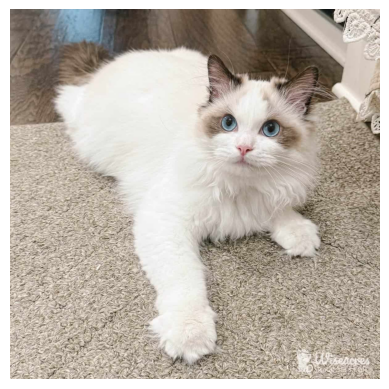

Результат розпізнавання: Ragdoll
Впевненість моделі: 78.90%


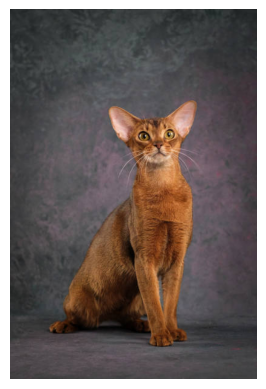

Результат розпізнавання: ABYSSINIAN (Cat)
Впевненість моделі: 73.36%


In [46]:
ragdoll1_url = "https://wiseacresragdolls.com/wp-content/uploads/2025/08/muffin-seal-bicolor-ragdoll-kitten-show-quality-hot-springs-arkansas-ficut.jpg"
Abyssinian1_url = "https://media.istockphoto.com/id/2196822731/photo/a-ginger-abyssinian-cat-poses-against-a-beautiful-background-in-a-photo-studio.jpg?s=612x612&w=0&k=20&c=lOwLuW4xwcLvlAyBvMzYCoi-WEjUwIXBK0MmlXQjc8E="
predict_pet(model, ragdoll1_url)
predict_pet(model, Abyssinian1_url)